<a href="https://sigmoidal.ai/en/">
  <img src="https://raw.githubusercontent.com/carlosfab/blog-sigmoidal/main/_assets/logo_sigmoidal.png" alt="Sigmoidal" width="240">
</a>

# Binary Cross-Entropy and Logistic Regression from First Principles

Companion material for the **Mathematics for Machine Learning** series on [Sigmoidal](https://sigmoidal.ai/en/).

Using only NumPy, this notebook implements the sigmoid function, derives binary cross-entropy from the Bernoulli distribution, and trains logistic regression with gradient descent. The final visualization connects predicted probabilities to the linear decision boundary.

## Imports and configuration

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.grid": True,
    "grid.alpha": 0.3,
})

np.random.seed(42)

## 1. The problem: predicting yes or no

We generate a synthetic binary-classification dataset with two features. Each point is an observation $(x^{(i)}, y^{(i)})$, with $y \in \{0, 1\}$. The two Gaussian clusters overlap partially, making the task nontrivial.

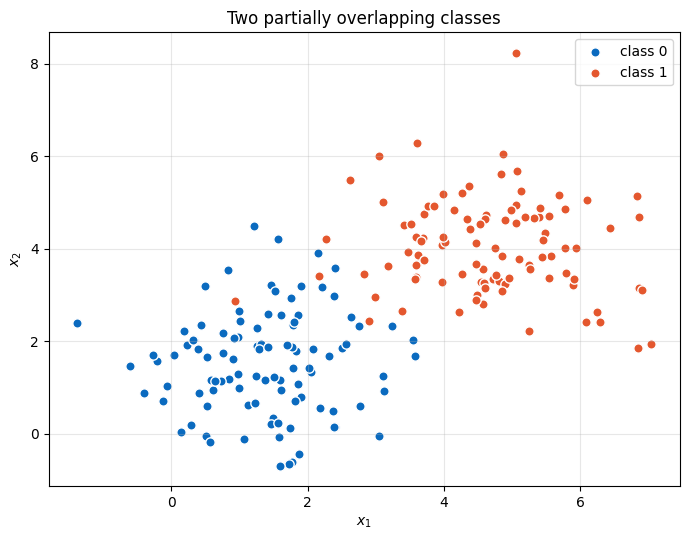

In [2]:
m = 200

# Class 0 and class 1: partially overlapping Gaussian clusters
X0 = np.random.randn(m // 2, 2) * 1.1 + np.array([1.5, 1.5])
X1 = np.random.randn(m // 2, 2) * 1.1 + np.array([4.5, 4.0])

X = np.vstack([X0, X1])
y = np.concatenate([np.zeros(m // 2), np.ones(m // 2)])

fig, ax = plt.subplots(figsize=(7, 5.5))
ax.scatter(X[y == 0, 0], X[y == 0, 1], c="#0A6ABF", edgecolor="white", s=45, label="class 0")
ax.scatter(X[y == 1, 0], X[y == 1, 1], c="#E4572E", edgecolor="white", s=45, label="class 1")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_title("Two partially overlapping classes")
ax.legend()
plt.tight_layout()
plt.show()

## 2. Mapping a linear score to probability with the sigmoid

The linear score $z = w^\top x + b$ ranges from $-\infty$ to $+\infty$, whereas a probability must lie in $(0, 1)$. The **sigmoid** maps the real line to that interval:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

In [3]:
def sigmoid(z):
    """Map any real-valued input to the interval (0, 1)."""
    return 1.0 / (1.0 + np.exp(-z))


for z in [-10, -2, 0, 2, 10]:
    print(f"sigmoid({z:+3d}) = {sigmoid(z):.4f}")

sigmoid(-10) = 0.0000
sigmoid( -2) = 0.1192
sigmoid( +0) = 0.5000
sigmoid( +2) = 0.8808
sigmoid(+10) = 1.0000


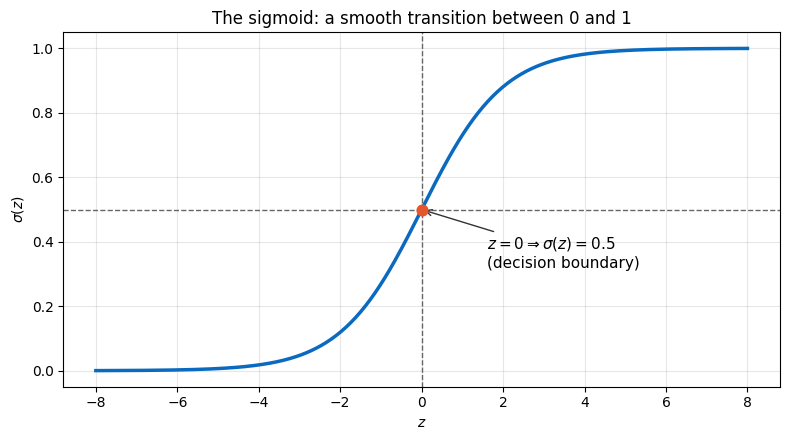

In [4]:
z = np.linspace(-8, 8, 400)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(z, sigmoid(z), color="#0A6ABF", linewidth=2.5)
ax.axhline(0.5, color="#666666", linestyle="--", linewidth=1)
ax.axvline(0.0, color="#666666", linestyle="--", linewidth=1)
ax.scatter([0], [0.5], color="#E4572E", zorder=5, s=60)
ax.annotate("$z = 0 \\Rightarrow \\sigma(z) = 0.5$\n(decision boundary)",
            xy=(0, 0.5), xytext=(1.6, 0.32), fontsize=11,
            arrowprops=dict(arrowstyle="->", color="#333333"))
ax.set_xlabel("$z$")
ax.set_ylabel("$\\sigma(z)$")
ax.set_title("The sigmoid: a smooth transition between 0 and 1")
plt.tight_layout()
plt.show()

## 3. Bernoulli likelihood and binary cross-entropy

A binary variable follows a **Bernoulli distribution**. Its conditional probability is $p(y \mid x; w, b) = \hat{p}^{\,y}(1 - \hat{p})^{1-y}$. Starting from the likelihood of independent observations, taking its logarithm, changing the sign, and averaging produces **binary cross-entropy**:

$$J(w, b) = -\frac{1}{m} \sum_{i=1}^{m} \Big[\, y^{(i)} \log \hat{p}^{(i)} + (1 - y^{(i)}) \log\big(1 - \hat{p}^{(i)}\big) \Big]$$

In [5]:
def bce(y, p_hat, eps=1e-12):
    """Return the mean binary cross-entropy."""
    p_hat = np.clip(p_hat, eps, 1 - eps)
    return -np.mean(y * np.log(p_hat) + (1 - y) * np.log(1 - p_hat))


# Compare a confident correct prediction, an uncertain one, and a confident error
print(f"confident correct prediction (y=1, p=0.99): loss = {bce(np.array([1.0]), np.array([0.99])):.4f}")
print(f"uncertain prediction        (y=1, p=0.50): loss = {bce(np.array([1.0]), np.array([0.50])):.4f}")
print(f"confident incorrect prediction (y=0, p=0.99): loss = {bce(np.array([0.0]), np.array([0.99])):.4f}")

confident correct prediction (y=1, p=0.99): loss = 0.0101
uncertain prediction        (y=1, p=0.50): loss = 0.6931
confident incorrect prediction (y=0, p=0.99): loss = 4.6052


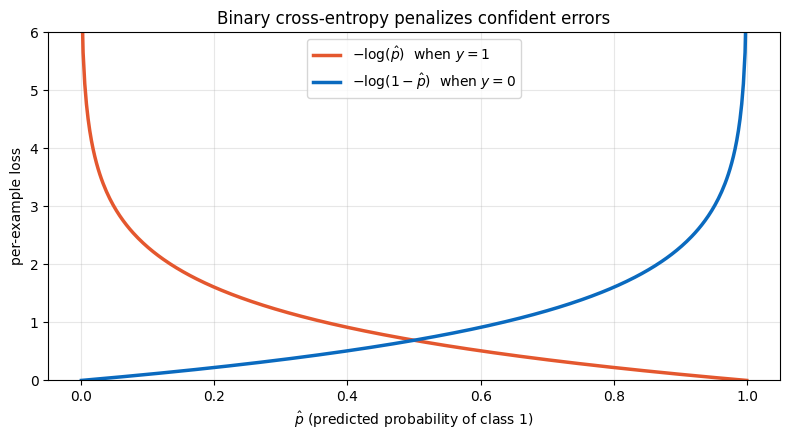

In [6]:
p = np.linspace(0.001, 0.999, 400)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(p, -np.log(p), color="#E4572E", linewidth=2.5, label=r"$-\log(\hat{p})$  when $y = 1$")
ax.plot(p, -np.log(1 - p), color="#0A6ABF", linewidth=2.5, label=r"$-\log(1 - \hat{p})$  when $y = 0$")
ax.set_xlabel(r"$\hat{p}$ (predicted probability of class 1)")
ax.set_ylabel("per-example loss")
ax.set_ylim(0, 6)
ax.set_title("Binary cross-entropy penalizes confident errors")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Training logistic regression

For logistic regression with binary cross-entropy, the gradients retain the interpretable residual-times-input form:

$$\frac{\partial J}{\partial w} = \frac{1}{m} \sum_{i=1}^{m} \big(\hat{p}^{(i)} - y^{(i)}\big)\, x^{(i)}, \qquad \frac{\partial J}{\partial b} = \frac{1}{m} \sum_{i=1}^{m} \big(\hat{p}^{(i)} - y^{(i)}\big)$$

In [7]:
def model(X, w, b):
    """Return the predicted probability of class 1."""
    return sigmoid(X @ w + b)


def gradient(X, y, w, b):
    """Compute the binary cross-entropy gradients."""
    residual = model(X, w, b) - y
    dw = X.T @ residual / len(y)
    db = np.mean(residual)
    return dw, db


def gradient_descent(X, y, w, b, alpha, n_iter):
    """Train logistic regression and return parameters and the loss history."""
    history = []
    for _ in range(n_iter):
        dw, db = gradient(X, y, w, b)
        w = w - alpha * dw      # simultaneous parameter update
        b = b - alpha * db
        history.append(bce(y, model(X, w, b)))
    return w, b, history


print(f"BCE at w=0, b=0 (neutral 50% prediction): {bce(y, model(X, np.zeros(2), 0.0)):.4f}")

w, b, history = gradient_descent(X, y, w=np.zeros(2), b=0.0, alpha=0.1, n_iter=3000)

y_pred = (model(X, w, b) >= 0.5).astype(float)
accuracy = np.mean(y_pred == y)

print(f"trained w = [{w[0]:.3f}, {w[1]:.3f}]")
print(f"trained b = {b:.3f}")
print(f"final BCE = {history[-1]:.4f}")
print(f"accuracy  = {accuracy:.3f}")

BCE at w=0, b=0 (neutral 50% prediction): 0.6931


trained w = [1.610, 1.167]
trained b = -7.924
final BCE = 0.0941
accuracy  = 0.965


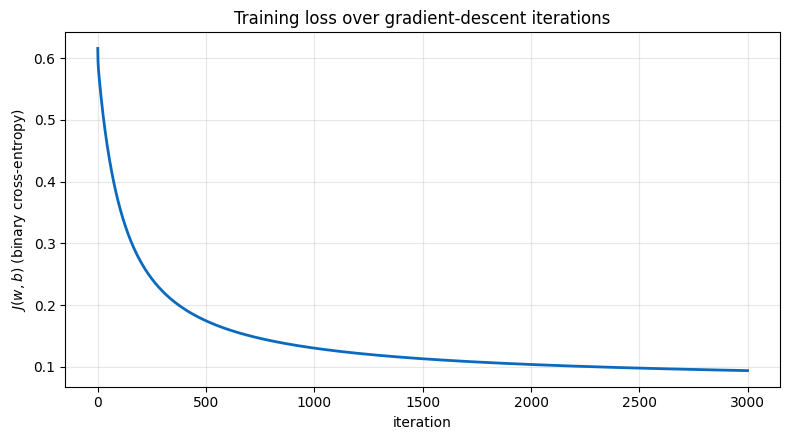

In [8]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(history, color="#0A6ABF", linewidth=2)
ax.set_xlabel("iteration")
ax.set_ylabel("$J(w, b)$ (binary cross-entropy)")
ax.set_title("Training loss over gradient-descent iterations")
plt.tight_layout()
plt.show()

## 5. Interpreting the decision boundary

The model predicts class 1 when $\hat{p} \geq 0.5$, equivalently when $z = w^\top x + b \geq 0$. The decision boundary is therefore the line $w^\top x + b = 0$. The color field below represents the probability predicted throughout the feature space.

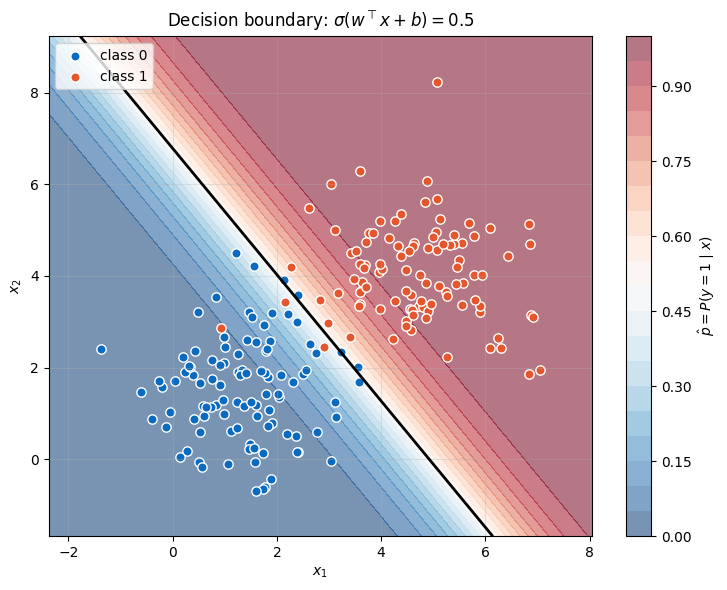

In [9]:
x1_grid, x2_grid = np.meshgrid(
    np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 300),
    np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 300),
)
grid = np.c_[x1_grid.ravel(), x2_grid.ravel()]
probs = model(grid, w, b).reshape(x1_grid.shape)

fig, ax = plt.subplots(figsize=(7.5, 6))
cs = ax.contourf(x1_grid, x2_grid, probs, levels=20, cmap="RdBu_r", alpha=0.55)
ax.contour(x1_grid, x2_grid, probs, levels=[0.5], colors="black", linewidths=2)
ax.scatter(X[y == 0, 0], X[y == 0, 1], c="#0A6ABF", edgecolor="white", s=45, label="class 0")
ax.scatter(X[y == 1, 0], X[y == 1, 1], c="#E4572E", edgecolor="white", s=45, label="class 1")
fig.colorbar(cs, ax=ax, label=r"$\hat{p} = P(y = 1 \mid x)$")
ax.set_xlabel(r"$x_1$")
ax.set_ylabel(r"$x_2$")
ax.set_title(r"Decision boundary: $\sigma(w^\top x + b) = 0.5$")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

---

This notebook accompanies the complete article on [sigmoidal.ai](https://sigmoidal.ai/en/).